In [37]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from numpy import random as rn
from scipy import stats
import scipy.stats as si
import seaborn as sns
from scipy.stats import norm

import pandas as pd
cpi = pd.read_csv('tesla.csv')
cpi.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


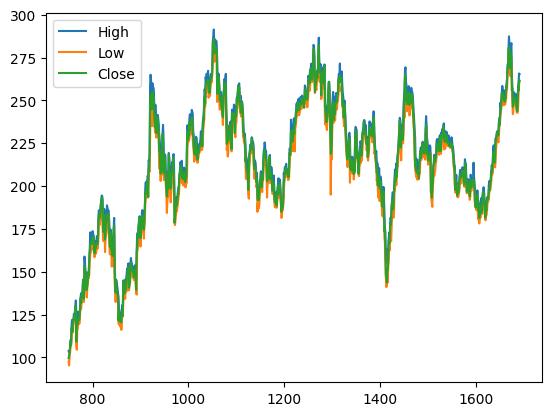

In [38]:
start = 750
stop  = len(cpi)
plt.plot(np.arange(start,stop),cpi['High'][start:stop],'-',label='High')
plt.plot(np.arange(start,stop),cpi['Low'][start:stop],'-',label='Low')
plt.plot(np.arange(start,stop),cpi['Close'][start:stop],'-',label='Close')
plt.legend()
plt.show()

In [39]:
cpi.tail()

,Date,Open,High,Low,Close,Volume,Adj Close
1687,3/13/2017,244.820007,246.850006,242.779999,246.169998,3010700,246.169998
1688,3/14/2017,246.110001,258.119995,246.020004,258.000000,7575500,258.000000
1689,3/15/2017,257.000000,261.000000,254.270004,255.729996,4816600,255.729996
1690,3/16/2017,262.399994,265.750000,259.059998,262.049988,7100400,262.049988
1691,3/17/2017,264.000000,265.329987,261.200012,261.500000,6475900,261.500000


In [48]:
a = 0.015
b = 0.001
df = cpi.copy()
# df = df.rename(columns={"Close": "S"})
df = df.drop(columns=['Open','High','Low','Volume','Adj Close'])
df.head()

,Date,Close
0,6/29/2010,23.889999
1,6/30/2010,23.830000
2,7/1/2010,21.959999
3,7/2/2010,19.200001
4,7/6/2010,16.110001


Original DataFrame:
           Date       Close       date
0     6/29/2010   23.889999 2010-06-29
1     6/30/2010   23.830000 2010-06-30
2      7/1/2010   21.959999 2010-07-01
3      7/2/2010   19.200001 2010-07-02
4      7/6/2010   16.110001 2010-07-06
...         ...         ...        ...
1687  3/13/2017  246.169998 2017-03-13
1688  3/14/2017  258.000000 2017-03-14
1689  3/15/2017  255.729996 2017-03-15
1690  3/16/2017  262.049988 2017-03-16
1691  3/17/2017  261.500000 2017-03-17

[1692 rows x 3 columns]

Filtered DataFrame (year > 2013):
           Date       Close       date
1136   1/2/2015  219.309998 2015-01-02
1137   1/5/2015  210.089996 2015-01-05
1138   1/6/2015  211.279999 2015-01-06
1139   1/7/2015  210.949997 2015-01-07
1140   1/8/2015  210.619995 2015-01-08
...         ...         ...        ...
1687  3/13/2017  246.169998 2017-03-13
1688  3/14/2017  258.000000 2017-03-14
1689  3/15/2017  255.729996 2017-03-15
1690  3/16/2017  262.049988 2017-03-16
1691  3/17/2017  261.50

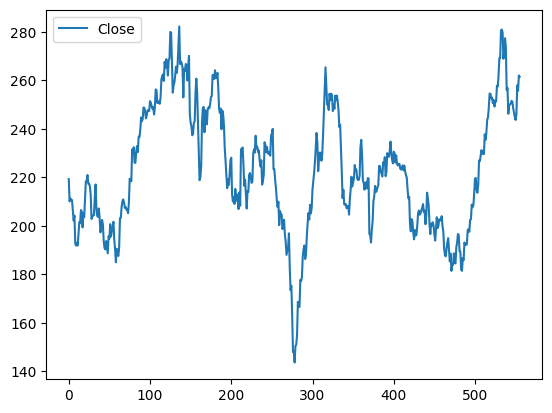

In [49]:
# 1. Convert the 'date_str' column to datetime
df['date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
# 2. Filter rows where the year is greater than 2013
filtered_df = df[df['date'].dt.year >= 2015]

print("Original DataFrame:")
print(df)
print("\nFiltered DataFrame (year > 2013):")
print(filtered_df)
plt.plot(np.arange(len(filtered_df)),filtered_df['Close'],'-',label='Close')
plt.legend()
plt.show()

In [50]:
# log-return r_t = log(S_t / S_{t-1})
df['Return'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)  # drop the first NaN

# Keep only columns we need
df = df[['date', 'Close', 'Return']]

In [51]:
df

,date,Close,Return
1,2010-06-30,23.830000,-0.002515
2,2010-07-01,21.959999,-0.081723
3,2010-07-02,19.200001,-0.134312
4,2010-07-06,16.110001,-0.175470
5,2010-07-07,15.800000,-0.019430
...,...,...,...
1687,2017-03-13,246.169998,0.010125
1688,2017-03-14,258.000000,0.046937
1689,2017-03-15,255.729996,-0.008837
1690,2017-03-16,262.049988,0.024413


In [57]:
# -----------------------------------------------------------------
# 3) CREATE SUPERVISED DATA (X, y) USING SLIDING WINDOWS
# -----------------------------------------------------------------
window_size = 5  # how many days of past returns we feed into the MLP

X = []
y = []  # we want to predict [mu, sigma]

returns = df['Return'].values
num_samples = len(returns)

for i in range(window_size, num_samples):
    # The input for day i is the returns from (i-window_size) to i-1
    window_returns = returns[i-window_size:i]
    
    # Our "labels" (targets) for that window:
    # mu_hat: mean of the returns in that window
    # sigma_hat: standard deviation of returns in that window
    mu_hat = np.mean(window_returns)
    sigma_hat = np.std(window_returns)
    
    X.append(window_returns)
    y.append([mu_hat, sigma_hat])

X = np.array(X)
y = np.array(y)

In [58]:
print("Shape of X:", X.shape)  # (num_samples-window_size, window_size)
print("Shape of y:", y.shape)  # (num_samples-window_size, 2)

Shape of X: (1686, 5)
Shape of y: (1686, 2)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
# -----------------------------------------------------------------
# 4) SPLIT INTO TRAIN/TEST (for demonstration)
# -----------------------------------------------------------------
train_ratio = 0.8
train_size = int(len(X) * train_ratio)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# -----------------------------------------------------------------
# 5) BUILD A SIMPLE MLP MODEL IN KERAS
# -----------------------------------------------------------------
model = Sequential([
    Dense(16, activation='relu', input_shape=(window_size,)),  # input: window_size returns
    Dense(8, activation='relu'),
    Dense(2, activation='linear')  # output: [mu, sigma]
])

# -----------------------------------------------------------------
# 6) COMPILE THE MODEL
# -----------------------------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'  # mean squared error for regression
)

model.summary()

# -----------------------------------------------------------------
# 7) TRAIN THE MODEL
# -----------------------------------------------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

# -----------------------------------------------------------------
# 8) EVALUATE ON TEST SET
# -----------------------------------------------------------------
mse = model.evaluate(X_test, y_test, verbose=0)
print("Test MSE:", mse)

# Predict some values
predictions = model.predict(X_test)
print("Predicted mu, sigma on test set:\n", predictions[:5])
print("Actual mu, sigma on test set:\n", y_test[:5])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250 (1000.00 B)

 Trainable params: 250 (1000.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.3579e-04 - val_loss: 1.3403e-04
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.4048e-04 - val_loss: 7.8167e-05
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5933e-04 - val_loss: 7.3357e-05
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4577e-04 - val_loss: 5.6462e-05
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1706e-04 - val_loss: 4.1801e-05
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.8971e-05 - val_loss: 4.4381e-05
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.6132e-05 - val_loss: 3.5410e-05
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.7480e-05 - val_loss: 2.9747e-05
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.2322e-05 - val_loss: 2.3714e-05
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.5587e-05 - val_loss: 2.9195e-05
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.9595e-05 - val_los